<a href="https://colab.research.google.com/github/siddharthsingh0617-spec/Geometric_Quantum_Machine_Learning/blob/main/geometric_qml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import random

# Fix seeds for reproducability
torch.backends.cudnn.deterministic = True
torch.manual_seed(16)
random.seed(16)


#  create an empty board
def create_board():
    return torch.tensor([[0, 0, 0], [0, 0, 0], [0, 0, 0]])


# Check for empty places on board
def possibilities(board):
    l = []
    for i in range(len(board)):
        for j in range(3):
            if board[i, j] == 0:
                l.append((i, j))
    return l


# Select a random place for the player
def random_place(board, player):
    selection = possibilities(board)
    current_loc = random.choice(selection)
    board[current_loc] = player
    return board


# Check if there is a winner by having 3 in a row
def row_win(board, player):
    for x in range(3):
        lista = []
        win = True

        for y in range(3):
            lista.append(board[x, y])

            if board[x, y] != player:
                win = False

        if win:
            break

    return win


# Check if there is a winner by having 3 in a column
def col_win(board, player):
    for x in range(3):
        win = True

        for y in range(3):
            if board[y, x] != player:
                win = False

        if win:
            break

    return win


# Check if there is a winner by having 3 along a diagonal
def diag_win(board, player):
    win1 = True
    win2 = True
    for x, y in [(0, 0), (1, 1), (2, 2)]:
        if board[x, y] != player:
            win1 = False

    for x, y in [(0, 2), (1, 1), (2, 0)]:
        if board[x, y] != player:
            win2 = False

    return win1 or win2


# Check if the win conditions have been met or if a draw has occurred
def evaluate_game(board):
    winner = None
    for player in [1, -1]:
        if row_win(board, player) or col_win(board, player) or diag_win(board, player):
            winner = player

    if torch.all(board != 0) and winner == None:
        winner = 0

    return winner


# Main function to start the game
def play_game():
    board, winner, counter = create_board(), None, 1
    while winner == None:
        for player in [1, -1]:
            board = random_place(board, player)
            counter += 1
            winner = evaluate_game(board)
            if winner != None:
                break

    return [board.flatten(), winner]


def create_dataset(size_for_each_winner):
    game_d = {-1: [], 0: [], 1: []}

    while min([len(v) for k, v in game_d.items()]) < size_for_each_winner:
        board, winner = play_game()
        if len(game_d[winner]) < size_for_each_winner:
            game_d[winner].append(board)

    res = []
    for winner, boards in game_d.items():
        res += [(board, winner) for board in boards]

    return res


NUM_TRAINING = 450
NUM_VALIDATION = 600

# Create datasets but with even numbers of each outcome
with torch.no_grad():
    dataset = create_dataset(NUM_TRAINING // 3)
    dataset_val = create_dataset(NUM_VALIDATION // 3)

In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 83.0 MB/s eta 0:00:00


In [ ]:
import pennylane as qp
import matplotlib.pyplot as plt

In [ ]:
dev=qp.device("default.qubit",wires=9)

In [ ]:
ob_center=qp.PauliZ(4)
ob_corner=(qp.PauliZ(0)+qp.PauliZ(2)+qp.PauliZ(6)+qp.PauliZ(8))*(1/4)
ob_edge=(qp.PauliZ(1)+qp.PauliZ(3)+qp.PauliZ(5)+qp.PauliZ(7))*(1/4)

In [ ]:
@qp.qnode(dev)
def circuit(x,p):
  qp.RX(x[0],wires=0)
  qp.RX(x[1],wires=1)
  qp.RX(x[2],wires=2)
  qp.RX(x[3],wires=3)
  qp.RX(x[4],wires=4)
  qp.RX(x[5],wires=5)
  qp.RX(x[6],wires=6)
  qp.RX(x[7],wires=7)
  qp.RX(x[8],wires=8)

  qp.RX(p[0],wires=4)
  qp.RY(p[1],wires=4)

  qp.RX(p[2],wires=0)
  qp.RX(p[2],wires=2)
  qp.RX(p[2],wires=6)
  qp.RX(p[2],wires=8)

  qp.RY(p[3],wires=0)
  qp.RY(p[3],wires=2)
  qp.RY(p[3],wires=6)
  qp.RY(p[3],wires=8)

  qp.RX(p[4],wires=1)
  qp.RX(p[4],wires=3)
  qp.RX(p[4],wires=5)
  qp.RX(p[4],wires=7)

  qp.RY(p[5],wires=1)
  qp.RY(p[5],wires=3)
  qp.RY(p[5],wires=5)
  qp.RY(p[5],wires=7)

  qp.CRY(p[6],wires=[0,1])
  qp.CRY(p[6],wires=[2,1])
  qp.CRY(p[6],wires=[2,5])
  qp.CRY(p[6],wires=[8,5])
  qp.CRY(p[6],wires=[8,7])
  qp.CRY(p[6],wires=[6,7])
  qp.CRY(p[6],wires=[6,3])
  qp.CRY(p[6],wires=[0,3])

  qp.CRY(p[7],wires=[4,0])
  qp.CRY(p[7],wires=[4,2])
  qp.CRY(p[7],wires=[4,6])
  qp.CRY(p[7],wires=[4,8])

  qp.CRY(p[8],wires=[1,4])
  qp.CRY(p[8],wires=[3,4])
  qp.CRY(p[8],wires=[5,4])
  qp.CRY(p[8],wires=[7,4])

  return [qp.expval(ob_center),qp.expval(ob_corner),qp.expval(ob_edge)]













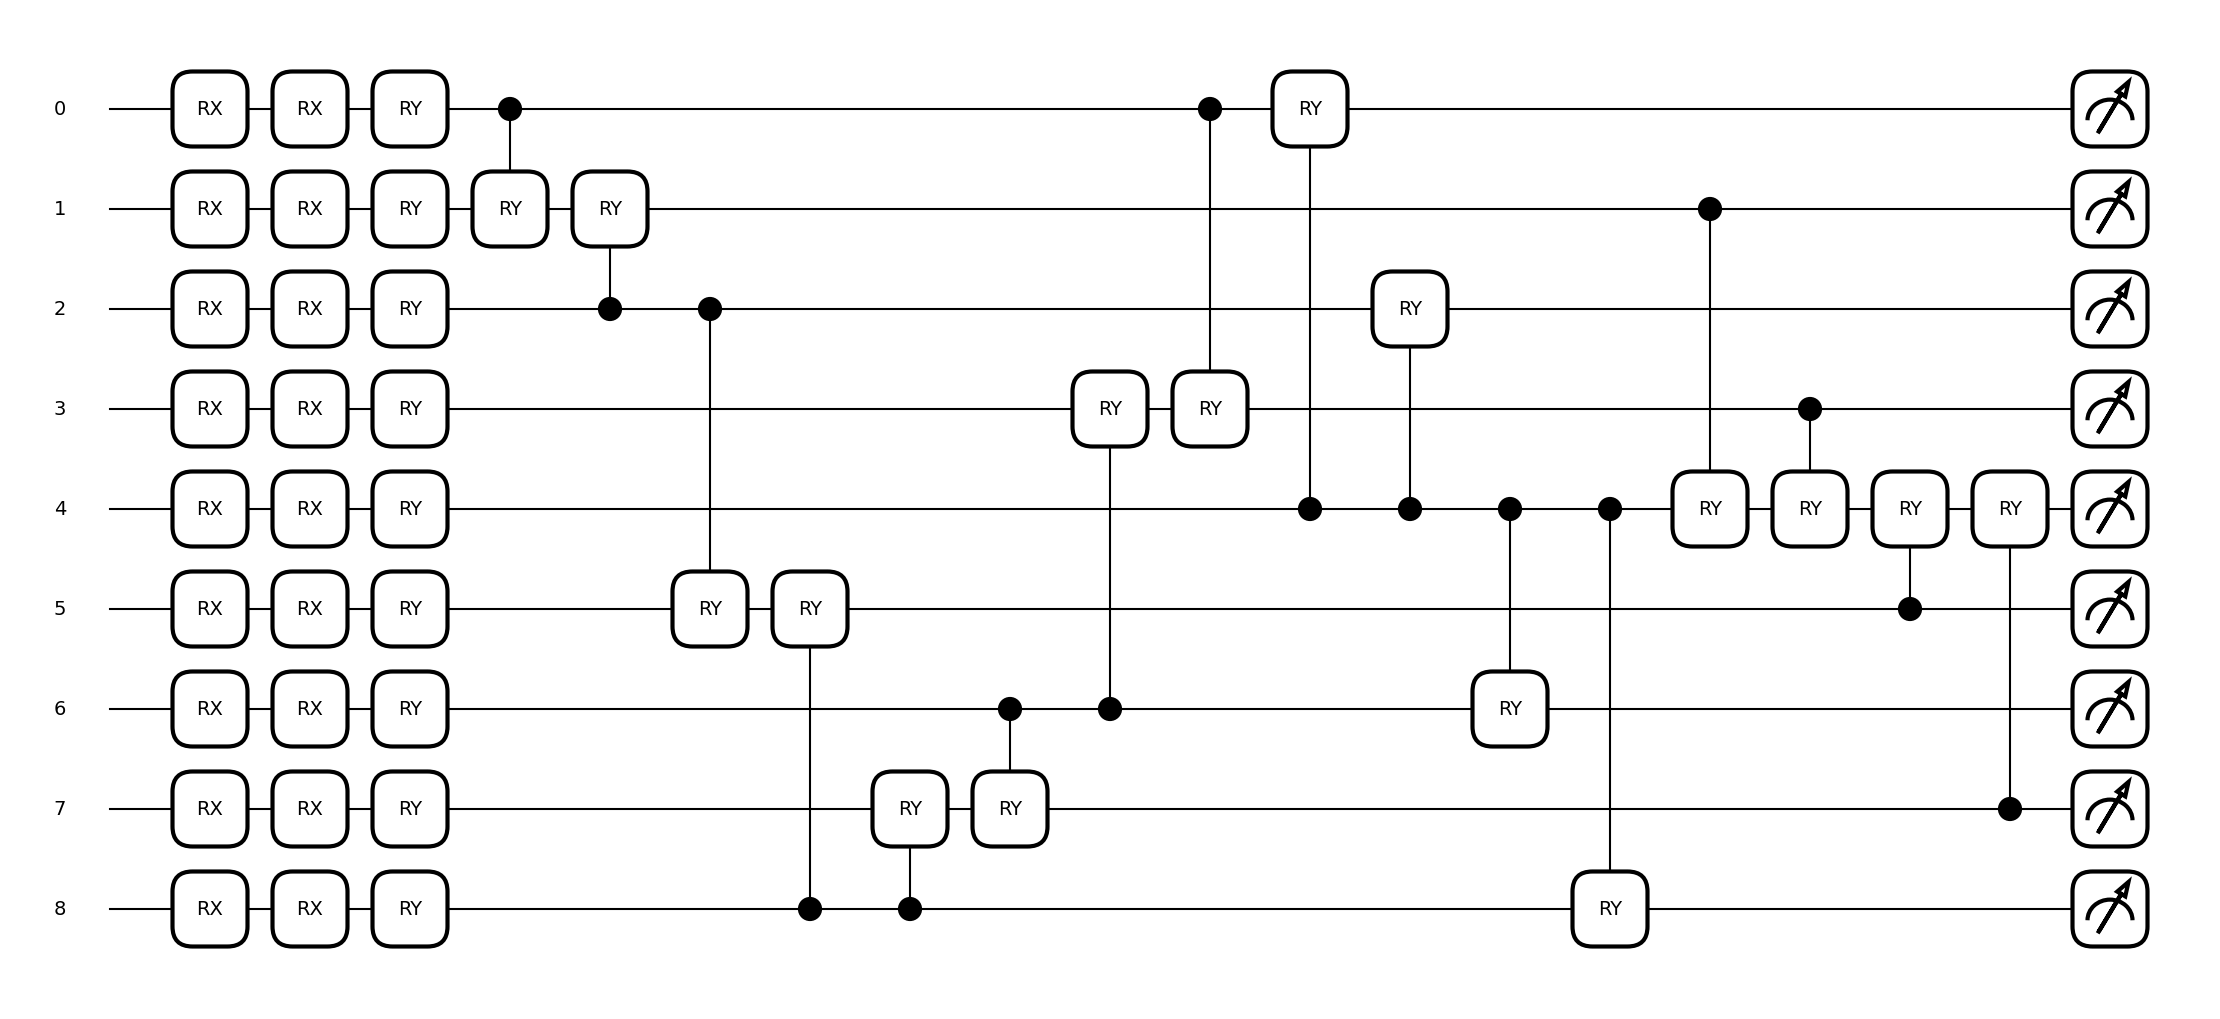

In [ ]:
fig, ax = qp.draw_mpl(circuit)([0] * 9, 18 * [0])


In [ ]:
@qp.qnode(dev)
def circuit_no_symm(x,p):
  qp.RX(x[0],wires=0)
  qp.RX(x[1],wires=1)
  qp.RX(x[2],wires=2)
  qp.RX(x[3],wires=3)
  qp.RX(x[4],wires=4)
  qp.RX(x[5],wires=5)
  qp.RX(x[6],wires=6)
  qp.RX(x[7],wires=7)
  qp.RX(x[8],wires=8)

  qp.RX(p[0],wires=4)
  qp.RY(p[1],wires=4)

  qp.RX(p[2],wires=0)
  qp.RX(p[3],wires=2)
  qp.RX(p[4],wires=6)
  qp.RX(p[5],wires=8)

  qp.RY(p[6],wires=0)
  qp.RY(p[7],wires=2)
  qp.RY(p[8],wires=6)
  qp.RY(p[9],wires=8)

  qp.RX(p[10],wires=1)
  qp.RX(p[11],wires=3)
  qp.RX(p[12],wires=5)
  qp.RX(p[13],wires=7)

  qp.RY(p[14],wires=1)
  qp.RY(p[15],wires=3)
  qp.RY(p[16],wires=5)
  qp.RY(p[17],wires=7)

  qp.CRY(p[18],wires=[0,1])
  qp.CRY(p[19],wires=[2,1])
  qp.CRY(p[20],wires=[2,5])
  qp.CRY(p[21],wires=[8,5])
  qp.CRY(p[22],wires=[8,7])
  qp.CRY(p[23],wires=[6,7])
  qp.CRY(p[24],wires=[6,3])
  qp.CRY(p[25],wires=[0,3])

  qp.CRY(p[26],wires=[4,0])
  qp.CRY(p[27],wires=[4,2])
  qp.CRY(p[28],wires=[4,6])
  qp.CRY(p[29],wires=[4,8])

  qp.CRY(p[30],wires=[1,4])
  qp.CRY(p[31],wires=[3,4])
  qp.CRY(p[32],wires=[5,4])
  qp.CRY(p[33],wires=[7,4])

  return [qp.expval(ob_center),qp.expval(ob_corner),qp.expval(ob_edge)]









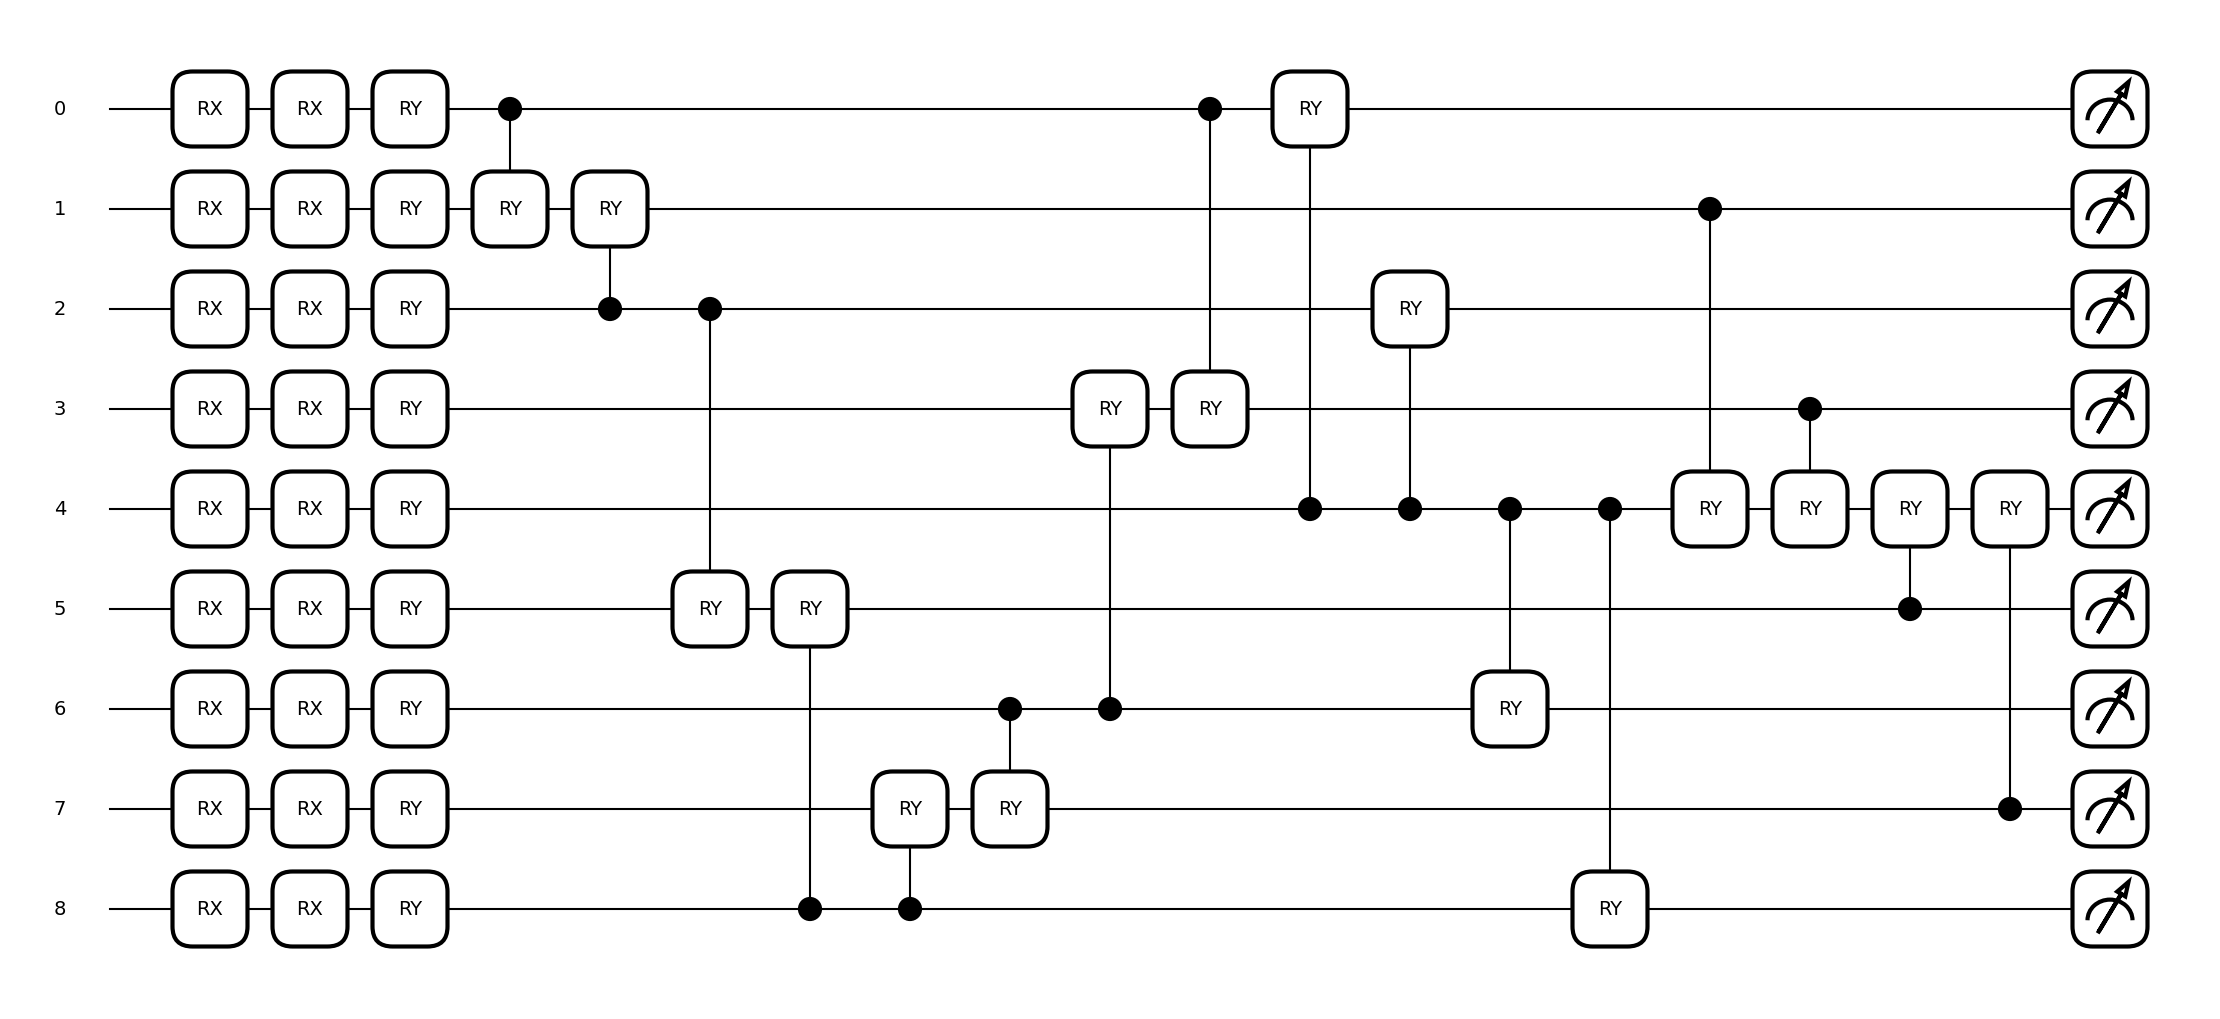

In [ ]:
fig, ax = qp.draw_mpl(circuit_no_symm)([0] * 9, [0] * 34)


In [ ]:
import math
def encode_game(game):
  board,res=game
  x=board*(2*math.pi)/3
  if(res==1):
    y=[-1,-1,1]
  elif(res==-1):
    y=[1,-1,-1]
  else:
    y=[-1,1,-1]
  return x,y


In [ ]:
def cost_function(params,input,target):
  output=torch.stack([torch.hstack(circuit(x,params)) for x in input])
  vec=output-target
  sum_sqr=torch.sum(vec*vec,dim=1)
  return torch.mean(sum_sqr)

In [ ]:
from torch import optim
import numpy as np

In [ ]:
params=0.01*torch.randn(9)
params.requires_grad=True
opt=optim.Adam([params],lr=1e-2)


In [ ]:
max_epoch=15
max_step=30
batch_size=10
encoded_dataset=list(zip(*[encode_game(game) for game in dataset]))
encoded_dataset_val=list(zip(*[encode_game(game) for game in dataset_val]))

In [16]:
def accuracy(p, x_val, y_val):
    with torch.no_grad():
        y_val = torch.tensor(y_val)
        y_out = torch.stack([torch.hstack(circuit(x, p)) for x in x_val])
        acc = torch.sum(torch.argmax(y_out, axis=1) == torch.argmax(y_val, axis=1))
        return acc / len(x_val)


print(f"accuracy without training = {accuracy(params, *encoded_dataset_val)}")

x_dataset = torch.stack(encoded_dataset[0])
y_dataset = torch.tensor(encoded_dataset[1], requires_grad=False)

saved_costs_sym = []
saved_accs_sym = []
for epoch in range(max_epoch):
    rand_idx = torch.randperm(len(x_dataset))
    # Shuffled dataset
    x_dataset = x_dataset[rand_idx]
    y_dataset = y_dataset[rand_idx]

    costs = []

    for step in range(max_step):
        x_batch = x_dataset[step * batch_size : (step + 1) * batch_size]
        y_batch = y_dataset[step * batch_size : (step + 1) * batch_size]

        def opt_func():
            opt.zero_grad()
            loss = cost_function(params, x_batch, y_batch)
            costs.append(loss.item())
            loss.backward()
            return loss

        opt.step(opt_func)

    cost = np.mean(costs)
    saved_costs_sym.append(cost)

    if (epoch + 1) % 1 == 0:
        # Compute validation accuracy
        acc_val = accuracy(params, *encoded_dataset_val)
        saved_accs_sym.append(acc_val)

        res = [epoch + 1, cost, acc_val]
        print("Epoch: {:2d} | Loss: {:3f} | Validation accuracy: {:3f}".format(*res))


accuracy without training = 0.2383333295583725
Epoch:  1 | Loss: 2.996221 | Validation accuracy: 0.153333
Epoch:  2 | Loss: 2.838961 | Validation accuracy: 0.415000
Epoch:  3 | Loss: 2.721652 | Validation accuracy: 0.535000
Epoch:  4 | Loss: 2.686487 | Validation accuracy: 0.553333
Epoch:  5 | Loss: 2.608699 | Validation accuracy: 0.548333
Epoch:  6 | Loss: 2.648471 | Validation accuracy: 0.591667
Epoch:  7 | Loss: 2.630698 | Validation accuracy: 0.585000
Epoch:  8 | Loss: 2.544674 | Validation accuracy: 0.585000
Epoch:  9 | Loss: 2.630653 | Validation accuracy: 0.570000
Epoch: 10 | Loss: 2.595081 | Validation accuracy: 0.576667
Epoch: 11 | Loss: 2.586225 | Validation accuracy: 0.578333
Epoch: 12 | Loss: 2.600443 | Validation accuracy: 0.578333
Epoch: 13 | Loss: 2.652541 | Validation accuracy: 0.576667
Epoch: 14 | Loss: 2.585265 | Validation accuracy: 0.580000
Epoch: 15 | Loss: 2.598611 | Validation accuracy: 0.580000


In [19]:
params = 0.01 * torch.randn(34)
params.requires_grad = True
opt = optim.Adam([params], lr=1e-2)

# calculate mean square error for this classification problem


def cost_function_no_sym(params, input, target):
    output = torch.stack([torch.hstack(circuit_no_symm(x, params)) for x in input])
    vec = output - target
    sum_sqr = torch.sum(vec * vec, dim=1)
    return torch.mean(sum_sqr)


max_epoch = 15
max_step = 30
batch_size = 15

encoded_dataset = list(zip(*[encode_game(game) for game in dataset]))
encoded_dataset_val = list(zip(*[encode_game(game) for game in dataset_val]))


def accuracy_no_sym(p, x_val, y_val):
    with torch.no_grad():
        y_val = torch.tensor(y_val)
        y_out = torch.stack([torch.hstack(circuit_no_symm(x, p)) for x in x_val])
        acc = torch.sum(torch.argmax(y_out, axis=1) == torch.argmax(y_val, axis=1))
        return acc / len(x_val)


print(f"accuracy without training = {accuracy_no_sym(params, *encoded_dataset_val)}")


x_dataset = torch.stack(encoded_dataset[0])
y_dataset = torch.tensor(encoded_dataset[1], requires_grad=False)

saved_costs = []
saved_accs = []
for epoch in range(max_epoch):
    rand_idx = torch.randperm(len(x_dataset))
    # Shuffled dataset
    x_dataset = x_dataset[rand_idx]
    y_dataset = y_dataset[rand_idx]

    costs = []

    for step in range(max_step):
        x_batch = x_dataset[step * batch_size : (step + 1) * batch_size]
        y_batch = y_dataset[step * batch_size : (step + 1) * batch_size]

        def opt_func():
            opt.zero_grad()
            loss = cost_function_no_sym(params, x_batch, y_batch)
            costs.append(loss.item())
            loss.backward()
            return loss

        opt.step(opt_func)

    cost = np.mean(costs)
    saved_costs.append(costs)

    if (epoch + 1) % 1 == 0:
        # Compute validation accuracy
        acc_val = accuracy_no_sym(params, *encoded_dataset_val)
        saved_accs.append(acc_val)

        res = [epoch + 1, cost, acc_val]
        print("Epoch: {:2d} | Loss: {:3f} | Validation accuracy: {:3f}".format(*res))

accuracy without training = 0.24833333492279053
Epoch:  1 | Loss: 3.013812 | Validation accuracy: 0.210000
Epoch:  2 | Loss: 2.891569 | Validation accuracy: 0.345000
Epoch:  3 | Loss: 2.783484 | Validation accuracy: 0.410000
Epoch:  4 | Loss: 2.718259 | Validation accuracy: 0.416667
Epoch:  5 | Loss: 2.678176 | Validation accuracy: 0.446667
Epoch:  6 | Loss: 2.650651 | Validation accuracy: 0.465000
Epoch:  7 | Loss: 2.631595 | Validation accuracy: 0.488333
Epoch:  8 | Loss: 2.615645 | Validation accuracy: 0.480000
Epoch:  9 | Loss: 2.604197 | Validation accuracy: 0.503333
Epoch: 10 | Loss: 2.596807 | Validation accuracy: 0.476667
Epoch: 11 | Loss: 2.587293 | Validation accuracy: 0.481667
Epoch: 12 | Loss: 2.581200 | Validation accuracy: 0.498333
Epoch: 13 | Loss: 2.574673 | Validation accuracy: 0.476667
Epoch: 14 | Loss: 2.571492 | Validation accuracy: 0.481667
Epoch: 15 | Loss: 2.566253 | Validation accuracy: 0.478333


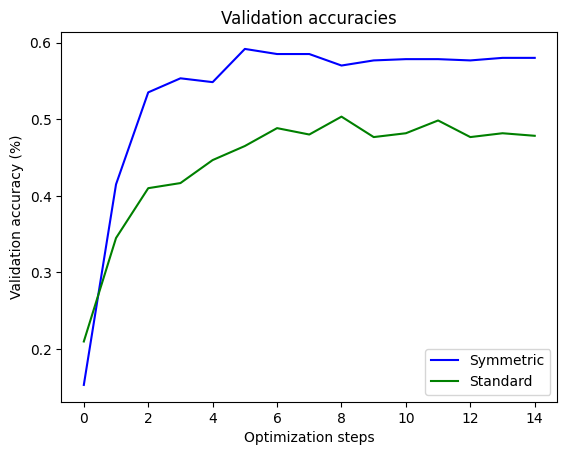

In [20]:
from matplotlib import pyplot as plt

plt.title("Validation accuracies")
plt.plot(saved_accs_sym, "b", label="Symmetric")
plt.plot(saved_accs, "g", label="Standard")

plt.ylabel("Validation accuracy (%)")
plt.xlabel("Optimization steps")
plt.legend()
plt.show()